In [1]:
import os
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from wompwomp import plot_alluvial
from ember.plots import plot_partition_specificity, plot_block_specificity, plot_sample_counts, plot_psi_blocks

In [2]:
# replace this path with the path for where the downloaded supplement file is located
supplement_file_path = "/home/nikki/Supplementary_data/"

In [4]:
# output path
output_path = "/home/nikki/swarna2025_figs/figs/fig1/"

# Fig1

## a

In [7]:
df_path = os.path.join(supplement_file_path, '8cube_across_tissues/psi_block_Strain.csv')
df = pd.read_csv(df_path, index_col = 0)

/tmp/ipykernel_290063/431561515.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(genes))


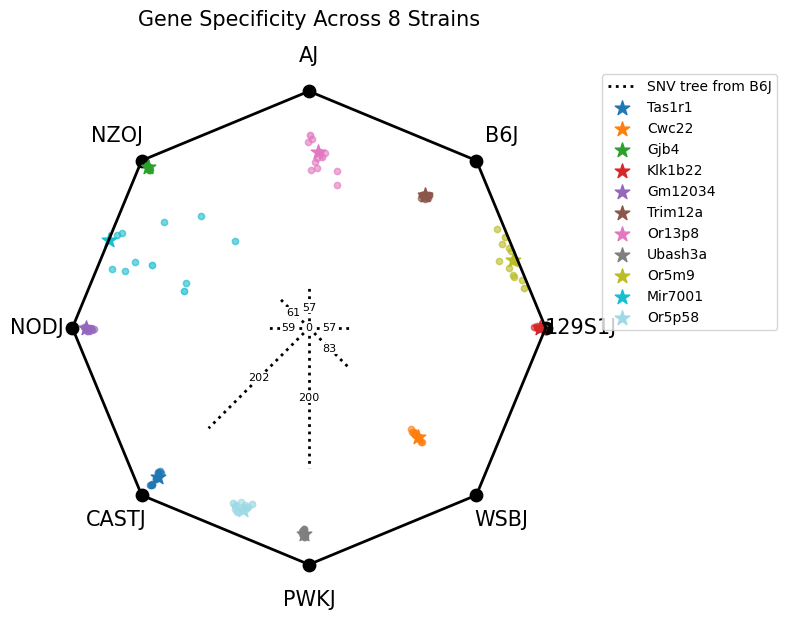

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.path import Path

genes = [
    'Tas1r1', 'Cwc22', 'Gjb4', 'Klk1b22', 'Gm12034',
    'Trim12a', 'Or13p8', 'Ubash3a', 'Or5m9', 'Mir7001', 'Or5p58'
]

strain_order = ['129S1J', 'B6J', 'AJ', 'NZOJ', 'NODJ',
                'CASTJ', 'PWKJ', 'WSBJ']

draw_dir = os.path.join(supplement_file_path, '8cube_across_tissues/gene_draws')

def load_saved_draws(gene, outdir=draw_dir):
    path = os.path.join(outdir, f"{gene}_draws.csv")
    return pd.read_csv(path, index_col=0)

# Geometry for octagon
n_strains = len(strain_order)
angles = np.linspace(0, 2 * np.pi, n_strains, endpoint=False)
vertices = np.stack((np.cos(angles), np.sin(angles)), axis=1)  # 8 corners
octagon = np.vstack([vertices, vertices[0]])

# plot set up
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(octagon[:, 0], octagon[:, 1], 'k-', lw=2)

# Label strains at the octagon corners
for i, (x, y) in enumerate(vertices):
    ax.scatter(x, y, color='black', s=80)
    ax.text(x * 1.15, y * 1.15, strain_order[i],
            ha='center', va='center', fontsize=15)

colors = cm.get_cmap('tab20', len(genes))

# plot each gene
for idx, gene in enumerate(genes):
    color = colors(idx)

    # geometric mean from your original df
    geo_mean = df[strain_order].loc[gene]
    geo_mean /= geo_mean.sum()
    geo_point = geo_mean @ vertices

    # load saved draws
    df_draws = load_saved_draws(gene)[strain_order]
    df_draws = df_draws.div(df_draws.sum(axis=1), axis=0)  # normalize
    draw_points = df_draws.values @ vertices

    # plot draws
    ax.scatter(draw_points[:, 0], draw_points[:, 1],
               color=color, alpha=0.2, s=20, marker='o')

    # geometric mean star
    ax.scatter(*geo_point, color=color,
               s=120, marker='*', label=gene)

# SNV tree overlap

snv_counts = {
    "PWKJ": 200, "NZOJ": 61, "NODJ": 59, "129S1J": 57,
    "AJ": 57, "WSBJ": 83, "CASTJ": 202, "B6J": 0
}

snv_array = np.array([snv_counts[s] for s in strain_order])
snv_scaled = snv_array / snv_array.max() * 0.6

for i, strain in enumerate(strain_order):
    direction = vertices[i]
    end_point = snv_scaled[i] * direction
    ax.plot([0, end_point[0]], [0, end_point[1]],
            color='black', linestyle='dotted', lw=2)

    mid = 0.5 * end_point
    ax.text(mid[0], mid[1], str(snv_counts[strain]),
            ha='center', va='center', fontsize=8,
            color='black',
            bbox=dict(facecolor='white', edgecolor='none', pad=0.2))

#legend + final formatting

snv_handle = Line2D([0], [0], color='black',
                    linestyle='dotted', lw=2,
                    label='SNV tree from B6J')

gene_handles, gene_labels = ax.get_legend_handles_labels()

ax.legend([snv_handle] + gene_handles,
          ['SNV tree from B6J'] + gene_labels,
          bbox_to_anchor=(1.05, 1),
          loc='upper left', fontsize=10)

ax.set_aspect('equal')
ax.set_title("Gene Specificity Across 8 Strains", pad=30, fontsize=15)
ax.axis('off')
plt.tight_layout()
plt.show()
fig_out_path = os.path.join(output_path, 'octagon.png')
fig.savefig(fig_out_path)

## b

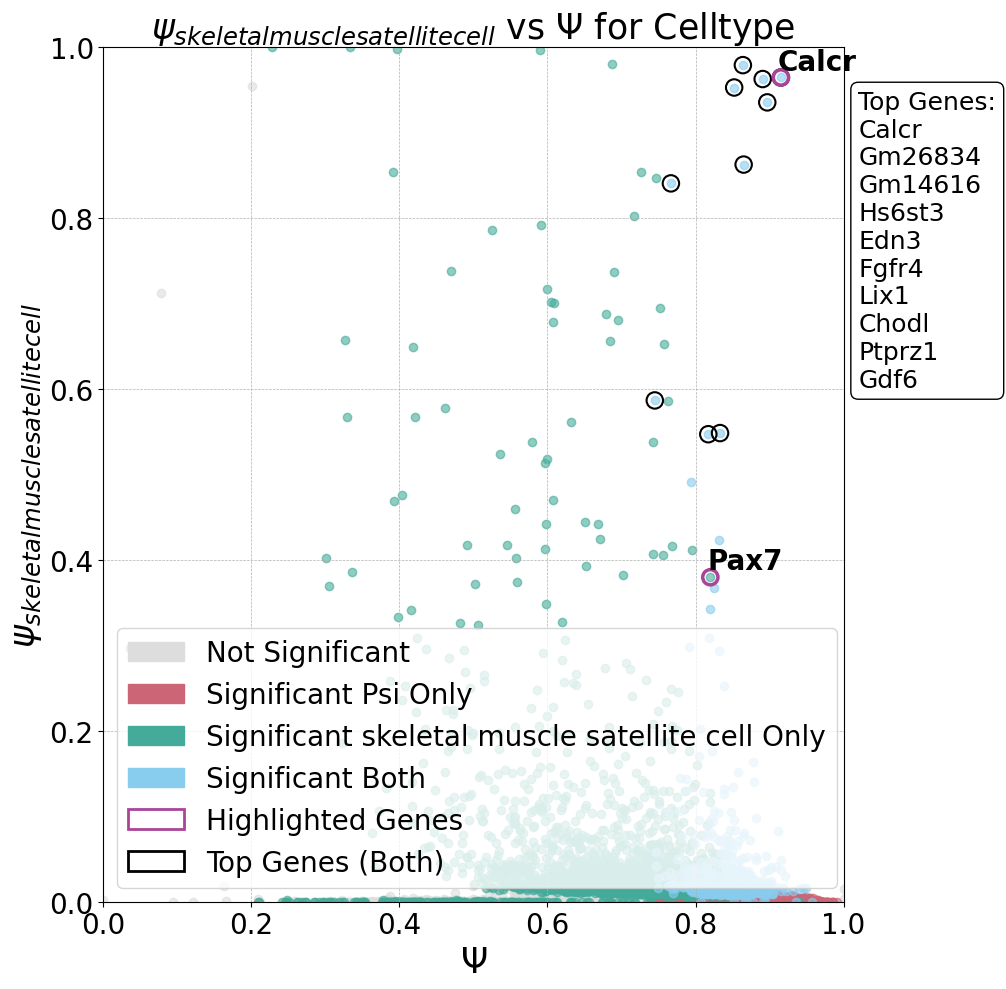

Block specificity plot saved to /home/nikki/swarna2025_figs/figs/fig1/block_specificity_scatterplot_Celltype_skeletal muscle satellite cell.png


In [9]:
pvals_path = os.path.join(supplement_file_path, 
                          '8cube_gastrocnemius/Gastrocnemius_Celltype_skeletal_muscle_satellite_cell_filtered_mincell100.csv')
plot_block_specificity(partition_label = 'Celltype', 
                       block_label = 'skeletal muscle satellite cell',
                       pvals_dir = pvals_path, 
                       save_dir = output_path, 
                       highlight_genes=['Calcr', 'Pax7'],
                       fontsize=22)

## c

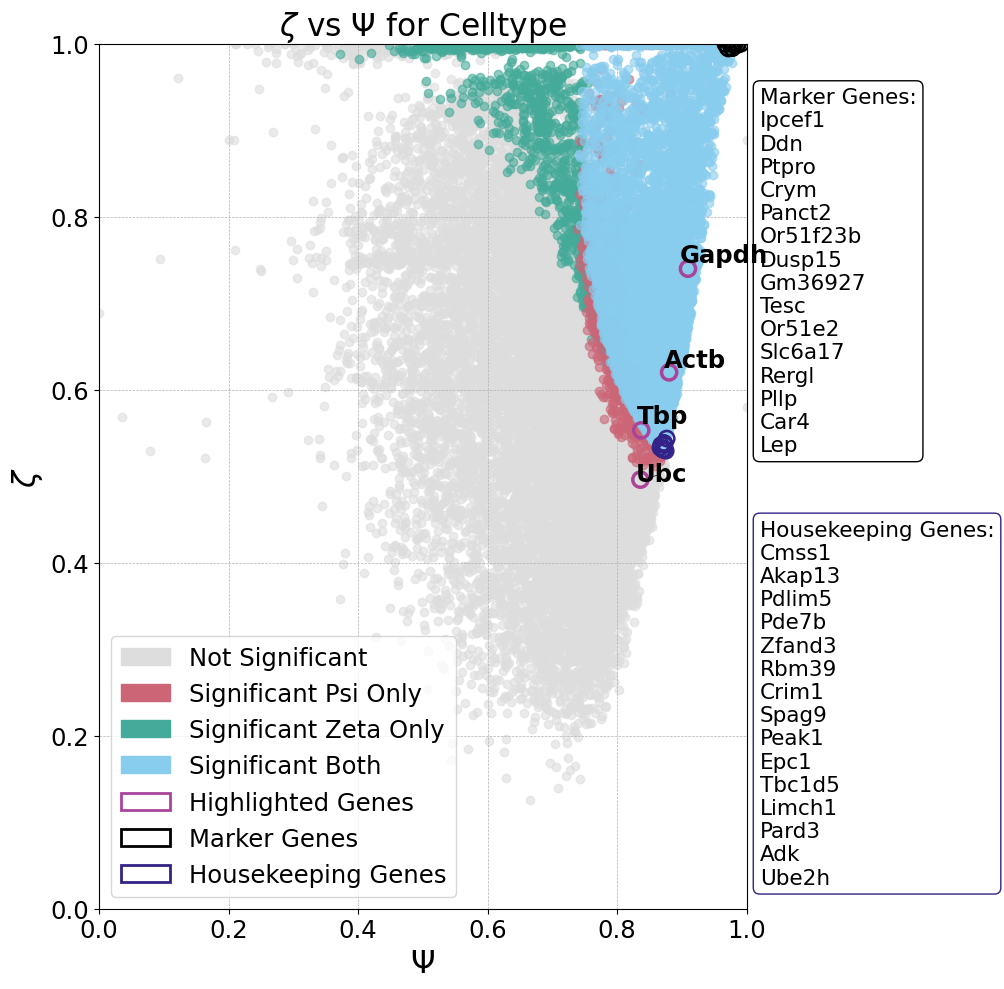

Partition specificity plot saved to /home/nikki/swarna2025_figs/figs/fig1/partition_specificity_scatterplot_Celltype.png


In [11]:
pvals_path = os.path.join(supplement_file_path, 
                          '8cube_gastrocnemius/Gastrocnemius_Celltype_skeletal_muscle_satellite_cell_filtered_mincell100.csv')

plot_partition_specificity(partition_label = 'Celltype', 
                           pvals_dir = pvals_path, 
                           save_dir = output_path, 
                           highlight_genes=['Gapdh', 'Actb', 'Ubc', 'Tbp'],
                           fontsize=19.5)

## d

Sorting Data with sorting algorithm = neighbornet
Sorting Distance matrix with algorithm neighbornet
Determining Optimal Cycle Start
neighbornet_objective for iteration 0 = 21981175223147.0
neighbornet_objective for iteration 1 = 24800158904221.0
neighbornet_objective for iteration 2 = 24700285562448.0
neighbornet_objective for iteration 3 = 24695509188365.0
neighbornet_objective for iteration 4 = 23767384777911.0
neighbornet_objective for iteration 5 = 23822571852592.0
neighbornet_objective for iteration 6 = 23760270809381.0
neighbornet_objective for iteration 7 = 24335328713747.0
neighbornet_objective for iteration 8 = 24362588469582.0
neighbornet_objective for iteration 9 = 24284718591905.0
neighbornet_objective for iteration 10 = 23711779924029.0
neighbornet_objective for iteration 11 = 23622555218506.0
neighbornet_objective for iteration 12 = 22941647417827.0
neighbornet_objective for iteration 13 = 22949020845182.0
neighbornet_objective for iteration 14 = 23291307857343.0
neighbo

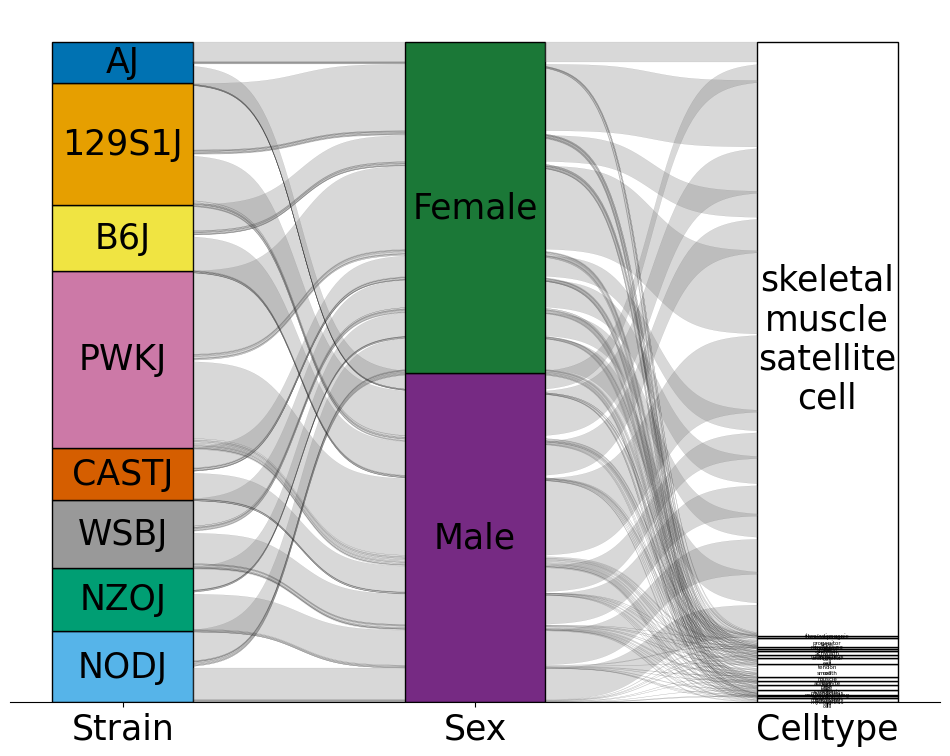

In [12]:
df_path = os.path.join(supplement_file_path, '8cube_gastrocnemius/Calcr_pseudobulk_wompwomp.csv')
df = pd.read_csv(df_path)

# cleaning out empty levels to improve effeciency
df = df[df['umi_total'] > 0]
df = df[['Sex', 'Genotype', 'celltype', 'umi_total']]
df = df.rename(columns={
    'Genotype': 'Strain',
    'celltype': 'Celltype'
})
df = df.groupby(['Sex', 'Strain', 'Celltype']).agg('sum').reset_index()


color_dict = {
    "129S1J": "#E69F00",   # orange
    "NODJ": "#56B4E9",     # sky blue
    "NZOJ": "#009E73",     # green
    "B6J": "#F0E442",      # yellow
    "AJ": "#0072B2",       # deep blue
    "CASTJ": "#D55E00",    # vermillion
    "PWKJ": "#CC79A7",     # purple-pink
    "WSBJ": "#999999",      # gray
    "Male": "#762A83",   # violet
    "Female": "#1B7837"      # dark green
    
}
fig, order_dict = plot_alluvial(df, #pandas data frame  
                  # general function arguments
                  graphing_columns = ['Strain','Sex', 'Celltype'],optimize_column_order = False, column_weights = 'umi_total',
                                color_alluvium = False, match_colors = False, verbose = True,
                                sorting_algorithm = 'neighbornet', return_order_dict = True, color_dict = color_dict,
                                fill_missing_colors = "#FFFFFF",
                                save_height=12, save_width=9, default_text_size=25, alluvial_alpha=0.3,resolution=30)

fig_out_path = os.path.join(output_path, 'Calcr_alluvial.png')
fig[0].savefig(fig_out_path)

## e

Sorting Data with sorting algorithm = neighbornet
Sorting Distance matrix with algorithm neighbornet
Determining Optimal Cycle Start
neighbornet_objective for iteration 0 = 6.026765209983547e+17
neighbornet_objective for iteration 1 = 5.982932647118931e+17
neighbornet_objective for iteration 2 = 5.969647088082124e+17
neighbornet_objective for iteration 3 = 5.972979589223946e+17
neighbornet_objective for iteration 4 = 6.211286509939393e+17
neighbornet_objective for iteration 5 = 6.162386813559489e+17
neighbornet_objective for iteration 6 = 6.17613431900435e+17
neighbornet_objective for iteration 7 = 6.333289913740636e+17
neighbornet_objective for iteration 8 = 6.335095696397308e+17
neighbornet_objective for iteration 9 = 5.976670374192763e+17
neighbornet_objective for iteration 10 = 5.974666700525164e+17
neighbornet_objective for iteration 11 = 6.006318176947754e+17
neighbornet_objective for iteration 12 = 5.954142351880637e+17
neighbornet_objective for iteration 13 = 5.942048902218636e

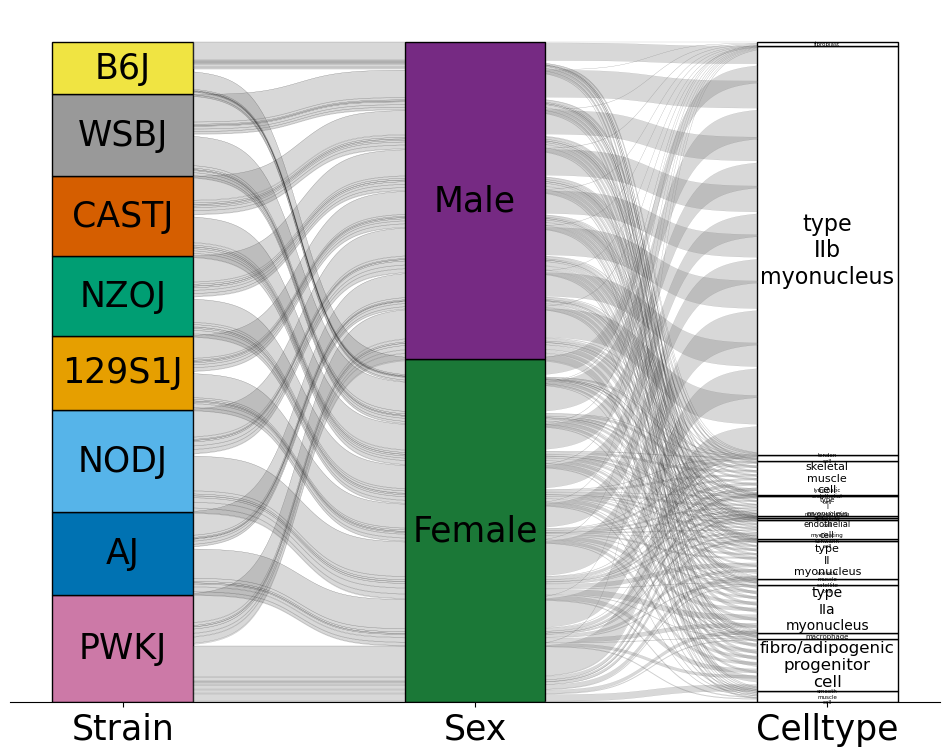

In [13]:
df_path = os.path.join(supplement_file_path, '8cube_gastrocnemius/Akap13_pseudobulk_wompwomp.csv')
df = pd.read_csv(df_path)

# cleaning out empty levels to improve effeciency
df = df[df['umi_total'] > 0]
df = df[['Sex', 'Genotype', 'celltype', 'umi_total']]
df = df.rename(columns={
    'Genotype': 'Strain',
    'celltype': 'Celltype'
})
df = df.groupby(['Sex', 'Strain', 'Celltype']).agg('sum').reset_index()


color_dict = {
    "129S1J": "#E69F00",   # orange
    "NODJ": "#56B4E9",     # sky blue
    "NZOJ": "#009E73",     # green
    "B6J": "#F0E442",      # yellow
    "AJ": "#0072B2",       # deep blue
    "CASTJ": "#D55E00",    # vermillion
    "PWKJ": "#CC79A7",     # purple-pink
    "WSBJ": "#999999",      # gray
    "Male": "#762A83",   # violet
    "Female": "#1B7837"      # dark green
    
}
fig, order_dict = plot_alluvial(df, #pandas data frame  
                  # general function arguments
                  graphing_columns = ['Strain','Sex', 'Celltype'],optimize_column_order = False, column_weights = 'umi_total',
                                color_alluvium = False, match_colors = False, verbose = True,
                                sorting_algorithm = 'neighbornet', return_order_dict = True, color_dict = color_dict,
                                fill_missing_colors = "#FFFFFF",
                                save_height=12, save_width=9, default_text_size=25, alluvial_alpha=0.3,resolution=30)

fig_out_path = os.path.join(output_path, 'Akap13_alluvial.png')
fig[0].savefig(fig_out_path)

## f

Sorting Data with sorting algorithm = neighbornet
Sorting Distance matrix with algorithm neighbornet
Determining Optimal Cycle Start
neighbornet_objective for iteration 0 = 243582959705.0
neighbornet_objective for iteration 1 = 248152030173.0
neighbornet_objective for iteration 2 = 330383505962.0
neighbornet_objective for iteration 3 = 331242746922.0
neighbornet_objective for iteration 4 = 399181023260.0
neighbornet_objective for iteration 5 = 399641882592.0
neighbornet_objective for iteration 6 = 398818517612.0
neighbornet_objective for iteration 7 = 404238831988.0
neighbornet_objective for iteration 8 = 408196010984.0
neighbornet_objective for iteration 9 = 235303209453.0
neighbornet_objective for iteration 10 = 236817111624.0
neighbornet_objective for iteration 11 = 235829285217.0
neighbornet_objective for iteration 12 = 237993653618.0
neighbornet_objective for iteration 13 = 253121449175.0
neighbornet_objective for iteration 14 = 265936209951.0
neighbornet_objective for iteration 1

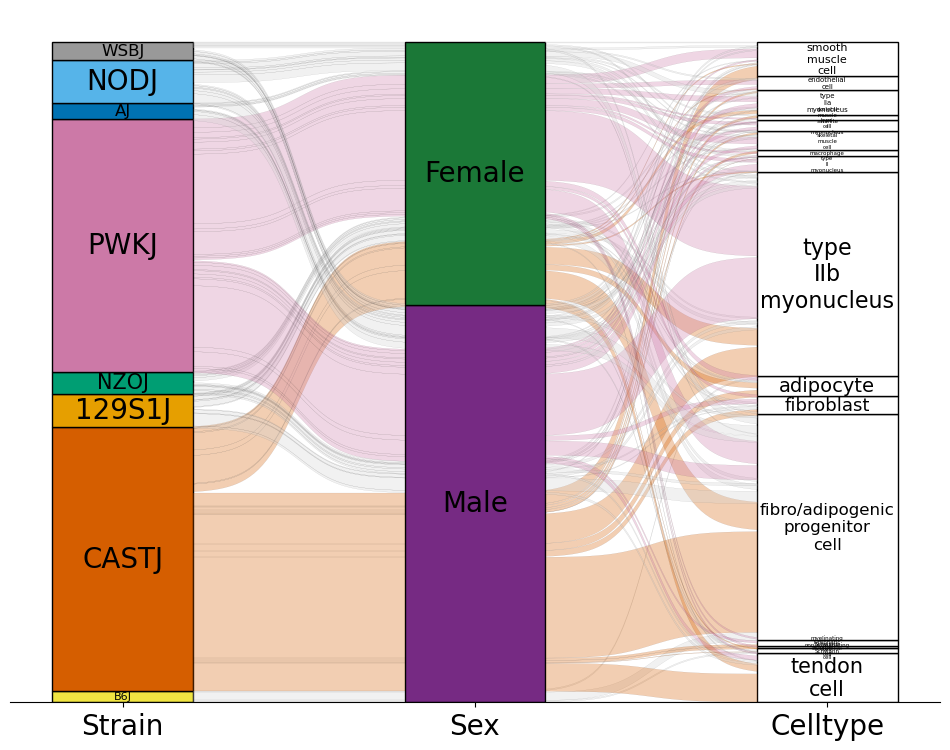

In [14]:
df_path = os.path.join(supplement_file_path, '8cube_gastrocnemius/Stk31_pseudobulk_wompwomp.csv')
df = pd.read_csv(df_path)
# cleaning out empty levels to improve effeciency
df = df[df['umi_total'] > 0]
df = df[['Sex', 'Genotype', 'celltype', 'umi_total', 'color']]
df = df.rename(columns={
    'Genotype': 'Strain',
    'celltype': 'Celltype'
})
df = df.groupby(['Sex', 'Strain', 'Celltype', 'color']).agg('sum').reset_index()


color_dict = {
    "129S1J": "#E69F00",   # orange
    "NODJ": "#56B4E9",     # sky blue
    "NZOJ": "#009E73",     # green
    "B6J": "#F0E442",      # yellow
    "AJ": "#0072B2",       # deep blue
    "CASTJ": "#D55E00",    # vermillion
    "PWKJ": "#CC79A7",     # purple-pink
    "WSBJ": "#999999",      # gray
    "Male": "#762A83",   # violet
    "Female": "#1B7837",      # dark green
    'CASTJ': '#D55E00',
    "PWKJ":'#CC79A7',
    'Other': 'lightgrey'
    
}
fig, order_dict = plot_alluvial(df, #pandas data frame  
                  # general function arguments
                  graphing_columns =  ['Strain', "Sex", 'Celltype'], column_weights = 'umi_total',
              alluvium_column = 'color', color_alluvium = True, match_colors = False, verbose = True,
             sorting_algorithm = 'neighbornet', return_order_dict = True, color_dict = color_dict,
                                fill_missing_colors = "#FFFFFF",optimize_column_order = False,
                            save_height=12, save_width=9, default_text_size=20, alluvial_alpha=0.3,resolution=30, 
                               savefig = True)
fig_out_path = os.path.join(output_path, 'Stk31_alluvial.png')
fig[0].savefig(fig_out_path)

## g

In [15]:
subset_gastroc_path = os.path.join(supplement_file_path, '8cube_gastrocnemius/Gastrocnemius_fig_1_genes.h5ad')
subset_gastroc = ad.read_h5ad(subset_gastroc_path)

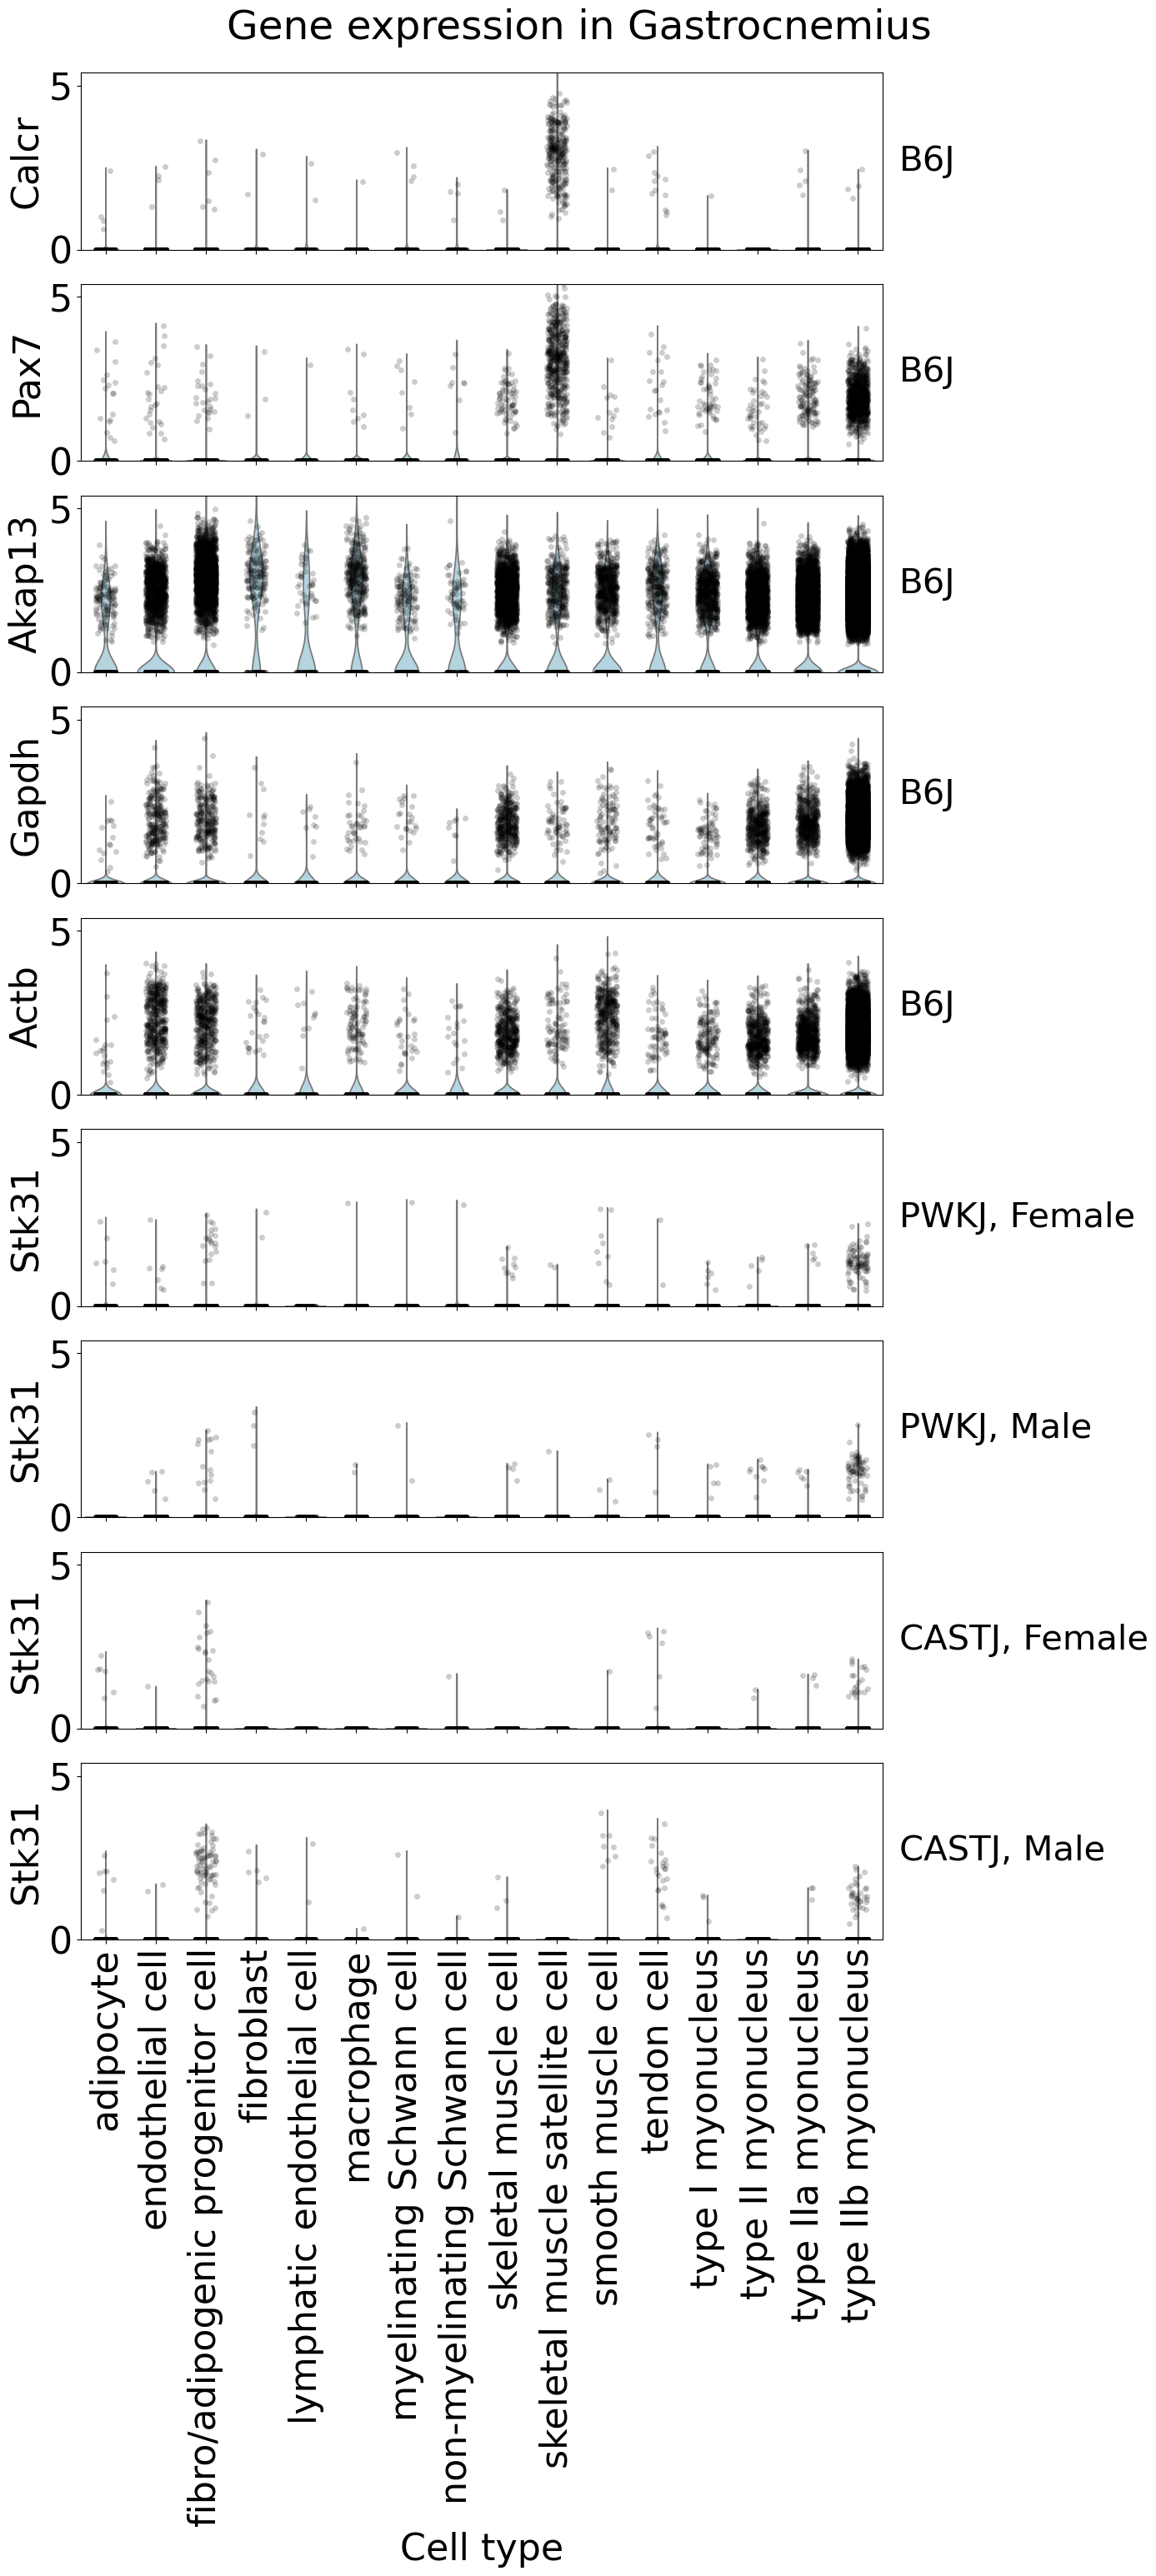

In [16]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

fontsize = 32

# --- Define conditions ---
genes_b6 = ["Calcr", "Pax7", "Akap13", "Gapdh", "Actb"]
stk31_conditions = [
    ("Stk31", "PWKJ", "Female"),
    ("Stk31", "PWKJ", "Male"),
    ("Stk31", "CASTJ", "Female"),
    ("Stk31", "CASTJ", "Male"),
]

# Build list of (gene, strain, sex) to plot
plot_conditions = []
for g in genes_b6:
    plot_conditions.append((g, "B6J", "both"))   # collapse sexes for B6J
plot_conditions.extend(stk31_conditions)

# --- Build dataframe for each condition ---
dfs = []
for gene, strain, sex in plot_conditions:
    # subset AnnData
    sub = subset_gastroc[subset_gastroc.obs["Genotype"] == strain].copy()
    if sex != "both":
        sub = sub[sub.obs["Sex"] == sex].copy()
    
    expr = sub[:, gene].X
    expr = expr.toarray().flatten() if hasattr(expr, "toarray") else expr.flatten()
    
    df = pd.DataFrame({
        "expression": expr,
        "celltype": sub.obs["celltype"].values,
        "Gene": gene,
        "strain": strain,
        "sex": sex
    })
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# --- Global ymax across all ---
ymax = df_all["expression"].max()

# --- Make stacked plots ---
fig, axes = plt.subplots(len(plot_conditions), 1, figsize=(14, 3.5*len(plot_conditions)), sharex=True, sharey=True)

fig.suptitle("Gene expression in Gastrocnemius", fontsize=fontsize+3)

if len(plot_conditions) == 1:
    axes = [axes]

for ax, (gene, strain, sex) in zip(axes, plot_conditions):
    df_cond = df_all[(df_all["Gene"] == gene) & 
                     (df_all["strain"] == strain) & 
                     ((df_all["sex"] == sex) if sex != "both" else True)]
    
    sns.violinplot(
        data=df_cond,
        x="celltype", y="expression",
        color="lightblue", inner=None, ax=ax
    )
    sns.stripplot(
        data=df_cond,
        x="celltype", y="expression",
        color="black", jitter=0.2, alpha=0.2, ax=ax
    )
    
    # y-axis label is gene
    ax.set_ylabel(gene, fontsize=fontsize)
    ax.set_xlabel("Cell type", fontsize=fontsize)
    ax.set_ylim(0, ymax)
    ax.tick_params(axis="x", rotation=90, labelsize=fontsize)
    ax.tick_params(axis="y", labelsize=fontsize)
    
    # annotation on right-hand side
    label = f"{strain}, {sex}" if sex != "both" else strain
    ax.annotate(label, xy=(1.02, 0.5), xycoords="axes fraction", 
                fontsize=fontsize-2, va="center")

plt.tight_layout(rect=[0,0,1,0.98])
plt.show()
fig_output_path = os.path.join(output_path, "violin_plots_gastrocnemius.png")
fig.savefig(fig_output_path)